# Assignment: Linear Models


## Q1 — Conceptual Questions


**1. What makes a model 'linear'? Linear in what?**

A model is 'linear' in its **parameters/coefficients**, not necessarily in the features. That means the predicted value is a weighted sum of the coefficients: $\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + ...$. Even if you include $x^2$ or $\log(x)$ as features, the model is still linear as long as the coefficients $b_j$ enter linearly.

**2. How do you interpret the coefficient for a dummy/one-hot-encoded variable?**

The trick is the intercept. **With an intercept**, you must drop one category (the reference group) to avoid perfect multicollinearity (the dummy variable trap). The coefficient on each remaining dummy represents the **difference in the mean of $y$** relative to the reference group, holding all else equal. **Without an intercept**, you can include all categories, and each coefficient equals the **mean of $y$** for that group.

**3. Can linear regression be used for classification?**

Technically yes (e.g. Linear Probability Model for binary outcomes), but it's generally not ideal. Predicted values can fall outside [0,1], probabilities aren't bounded, and the error distribution violates OLS assumptions. Logistic regression is preferred for classification.

**4. What are signs that your linear model is over-fitting?**

- Training $R^2$ is much higher than test $R^2$
- Training RMSE is much lower than test RMSE
- Model has many features relative to observations
- Coefficients are very large in magnitude
- Adding more features keeps improving training error but hurts test error

**5. Explain multicollinearity using two-stage least squares (2SLS)**

Multicollinearity occurs when two or more predictors are highly correlated, making it hard to isolate each variable's individual effect — the OLS estimates become unstable and have high variance. 2SLS addresses a related problem (endogeneity) by finding an **instrument** $z$ that is correlated with the problematic regressor $x$ but not with the error. In Stage 1, you regress $x$ on $z$ and get $\hat{x}$ (the 'clean' variation in $x$). In Stage 2, you regress $y$ on $\hat{x}$. By stripping out the collinear/endogenous part of $x$, the Stage 2 coefficient is better identified.

**6. How can you incorporate nonlinear relationships into a linear model?**

By transforming the features or target variable. Common approaches:
- **Polynomial features**: include $x^2$, $x^3$, etc.
- **Log/arcsinh transformation**: apply $\log(x)$ or $\log(y)$ to compress skewed distributions
- **Interaction terms**: $x_1 \cdot x_2$ to capture joint effects
- **Splines**: piecewise polynomial functions of $x$
The model remains linear in its coefficients even after these transformations.

**7. Interpretation of intercept, slope, and dummy coefficients**

- **Intercept $b_0$**: The predicted value of $y$ when all predictors equal zero. If variables are demeaned, it equals $\bar{y}$.
- **Slope $b_j$**: A one-unit increase in $x_j$ is associated with a $b_j$ change in $y$, holding all other variables constant.
- **Dummy coefficient**: The difference in the predicted mean of $y$ for that category relative to the reference (dropped) category, holding all else equal.

## Q2 — Airbnb NYC Pricing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_csv('/content/Q1_clean.csv')
df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True)
print(df.shape)
df.head()

(22153, 5)


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


### Q2.1 — Average prices and KDE plots by Neighbourhood

                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378

Most expensive borough: Manhattan


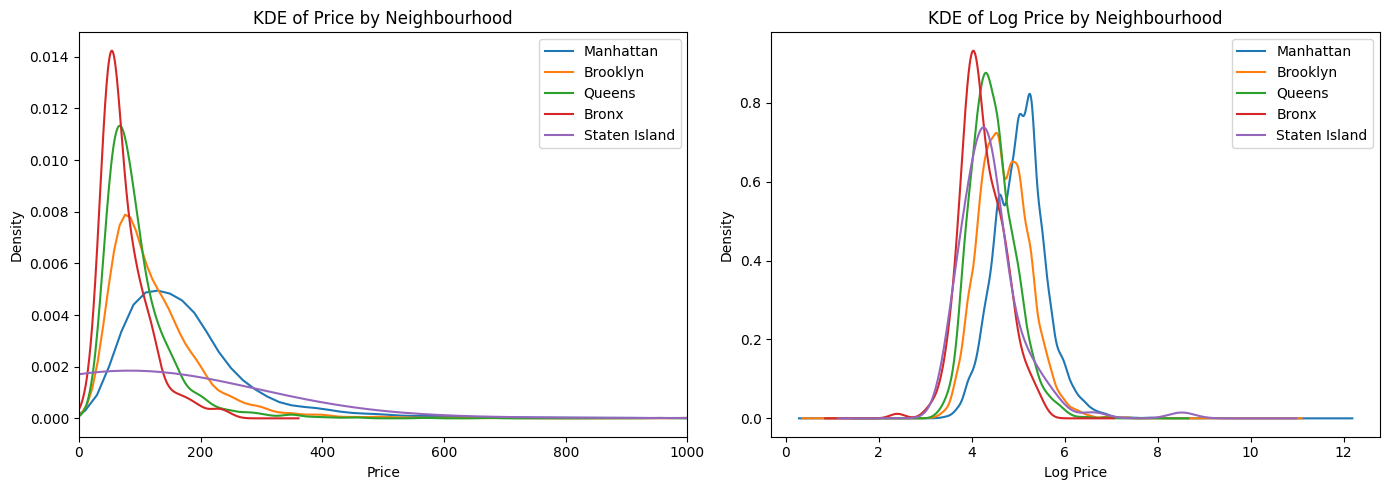

In [2]:
# Average price and review score by neighbourhood
summary = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values('Price', ascending=False)
print(summary)
print(f"\nMost expensive borough: {summary['Price'].idxmax()}")

# KDE of price by neighbourhood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == hood]['Price'].dropna()
    subset.plot.kde(ax=axes[0], label=hood)
axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].legend()
axes[0].set_xlim(0, 1000)

df['log_price'] = np.log1p(df['Price'])
for hood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == hood]['log_price'].dropna()
    subset.plot.kde(ax=axes[1], label=hood)
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

### Q2.2 — Regression on Neighbourhood dummies, NO intercept

In [3]:
# One-hot encode ALL categories (no drop), no intercept
dummies_all = pd.get_dummies(df['Neighbourhood'], prefix='hood')
X_no_intercept = dummies_all.astype(int)
y = df['Price']

model_no_int = LinearRegression(fit_intercept=False)
model_no_int.fit(X_no_intercept, y)

coef_no_int = pd.Series(model_no_int.coef_, index=X_no_intercept.columns).sort_values(ascending=False)
print("Coefficients (no intercept):")
print(coef_no_int)
print("\nMean prices from part 1:")
print(summary['Price'])
print("\n>> Pattern: Each coefficient equals the group mean of Price. Regressing on dummies without intercept = group means.")

Coefficients (no intercept):
hood_Manhattan        183.664286
hood_Staten Island    146.166667
hood_Brooklyn         127.747378
hood_Queens            96.857233
hood_Bronx             75.276498
dtype: float64

Mean prices from part 1:
Neighbourhood
Manhattan        183.664286
Staten Island    146.166667
Brooklyn         127.747378
Queens            96.857233
Bronx             75.276498
Name: Price, dtype: float64

>> Pattern: Each coefficient equals the group mean of Price. Regressing on dummies without intercept = group means.


### Q2.3 — Regression on Neighbourhood dummies, WITH intercept

In [4]:
# Drop one category to avoid dummy variable trap
dummies_drop = pd.get_dummies(df['Neighbourhood'], prefix='hood', drop_first=True)
X_with_intercept = dummies_drop.astype(int)

model_int = LinearRegression(fit_intercept=True)
model_int.fit(X_with_intercept, y)

print(f"Intercept: {model_int.intercept_:.2f}")
coef_int = pd.Series(model_int.coef_, index=X_with_intercept.columns)
print("\nCoefficients (with intercept):")
print(coef_int)

# The reference category
ref_cat = [c for c in dummies_all.columns if c not in ['hood_' + h for h in df['Neighbourhood'].unique() if 'hood_' + h in dummies_drop.columns]]
print(f"\nIntercept = mean price of the reference (dropped) category")
print("Each coefficient = difference in mean price vs. the reference category")
print("To recover part 2 coefficients: add the intercept to each dummy coefficient")
print("\nRecovered group means (intercept + coef):")
recovered = coef_int + model_int.intercept_
print(recovered)

Intercept: 75.28

Coefficients (with intercept):
hood_Brooklyn          52.470881
hood_Manhattan        108.387789
hood_Queens            21.580735
hood_Staten Island     70.890169
dtype: float64

Intercept = mean price of the reference (dropped) category
Each coefficient = difference in mean price vs. the reference category
To recover part 2 coefficients: add the intercept to each dummy coefficient

Recovered group means (intercept + coef):
hood_Brooklyn         127.747378
hood_Manhattan        183.664286
hood_Queens            96.857233
hood_Staten Island    146.166667
dtype: float64


### Q2.4 — Regression: Price ~ Review Scores Rating + Neighbourhood

In [5]:
df_clean = df[['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type']].dropna()

dummies_hood = pd.get_dummies(df_clean['Neighbourhood'], prefix='hood', drop_first=True).astype(int)
X4 = pd.concat([df_clean[['Review Scores Rating']].reset_index(drop=True),
                dummies_hood.reset_index(drop=True)], axis=1)
y4 = df_clean['Price'].reset_index(drop=True)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

model4 = LinearRegression()
model4.fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)

r2_4 = r2_score(y4_test, y4_pred)
rmse_4 = np.sqrt(mean_squared_error(y4_test, y4_pred))
coef_review_4 = model4.coef_[0]

print(f"R² (test): {r2_4:.4f}")
print(f"RMSE (test): {rmse_4:.2f}")
print(f"Coefficient on Review Scores Rating: {coef_review_4:.4f}")

R² (test): 0.0459
RMSE (test): 140.92
Coefficient on Review Scores Rating: 1.2119


### Q2.5 — Regression: Price ~ Review Scores Rating + Neighbourhood + Property Type

In [6]:
dummies_prop = pd.get_dummies(df_clean['Property Type'], prefix='prop', drop_first=True).astype(int)
X5 = pd.concat([df_clean[['Review Scores Rating']].reset_index(drop=True),
                dummies_hood.reset_index(drop=True),
                dummies_prop.reset_index(drop=True)], axis=1)
y5 = df_clean['Price'].reset_index(drop=True)

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

model5 = LinearRegression()
model5.fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)

r2_5 = r2_score(y5_test, y5_pred)
rmse_5 = np.sqrt(mean_squared_error(y5_test, y5_pred))
coef_review_5 = model5.coef_[0]

print(f"R² (test): {r2_5:.4f}")
print(f"RMSE (test): {rmse_5:.2f}")
print(f"Coefficient on Review Scores Rating: {coef_review_5:.4f}")

# Most expensive property type
prop_coefs = pd.Series(model5.coef_[len(dummies_hood.columns)+1:], index=dummies_prop.columns)
print(f"\nMost expensive property type (vs reference): {prop_coefs.idxmax()} (coef={prop_coefs.max():.2f})")

R² (test): 0.0542
RMSE (test): 140.30
Coefficient on Review Scores Rating: 1.2010

Most expensive property type (vs reference): prop_Bungalow (coef=83.97)


### Q2.6 — Why does the coefficient on Review Scores Rating change between Q2.4 and Q2.5?

In multiple linear regression, each coefficient represents the effect of that variable **holding all other variables constant**. When we add `Property Type` in part 5, the coefficient on `Review Scores Rating` changes because `Property Type` was previously an **omitted variable** — it is correlated with both `Review Scores Rating` and `Price`. Adding it controls for that variation, so the coefficient in part 5 is a more **partial/conditional** effect of review scores, net of property type differences.

## Q3 — Car Prices Case Study


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

cars = pd.read_csv('/content/cars_hw.csv')
print(cars.shape)
cars.head()

(976, 12)


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


### Q3.1 — Data Cleaning

In [8]:
print(cars.dtypes)
print(cars.isnull().sum())
print(cars.describe())

Unnamed: 0            int64
Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run           int64
No_of_Owners         object
Seating_Capacity      int64
Fuel_Type            object
Transmission         object
Transmission_Type    object
Price                 int64
dtype: object
Unnamed: 0           0
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64
       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000         

In [9]:
# Drop rows with missing Price
cars = cars.dropna(subset=['Price'])

# Fill or drop remaining nulls
cars = cars.dropna()

# Remove extreme outliers in Price using IQR
Q1_p = cars['Price'].quantile(0.01)
Q3_p = cars['Price'].quantile(0.99)
cars = cars[(cars['Price'] >= Q1_p) & (cars['Price'] <= Q3_p)]

# Log-transform Price and Mileage_Run to handle skew
cars['log_Price'] = np.log1p(cars['Price'])
cars['log_Mileage'] = np.log1p(cars['Mileage_Run'])

# Make_Year: keep as numeric
cars['Make_Year'] = pd.to_numeric(cars['Make_Year'], errors='coerce')
cars = cars.dropna(subset=['Make_Year'])

print(f"Clean dataset shape: {cars.shape}")
cars.describe()

Clean dataset shape: (956, 14)


,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price,log_Price,log_Mileage
count,956.000000,956.000000,956.000000,956.000000,9.560000e+02,956.000000,956.000000
mean,488.501046,2016.975941,41474.834728,5.096234,7.319100e+05,13.409514,10.412606
std,282.437682,2.781097,24414.447565,0.445038,3.388222e+05,0.427444,0.735746
min,1.000000,2011.000000,1117.000000,5.000000,2.710000e+05,12.509878,7.019297
25%,244.750000,2015.000000,22544.000000,5.000000,4.827500e+05,13.087256,10.023269
50%,485.500000,2017.000000,37299.000000,5.000000,6.665000e+05,13.409797,10.526749
75%,735.250000,2019.000000,57421.250000,5.000000,8.772500e+05,13.684548,10.958187
max,976.000000,2022.000000,99495.000000,8.000000,1.978000e+06,14.497597,11.507873


### Q3.2 — Summarize Price

count    9.560000e+02
mean     7.319100e+05
std      3.388222e+05
min      2.710000e+05
25%      4.827500e+05
50%      6.665000e+05
75%      8.772500e+05
max      1.978000e+06
Name: Price, dtype: float64


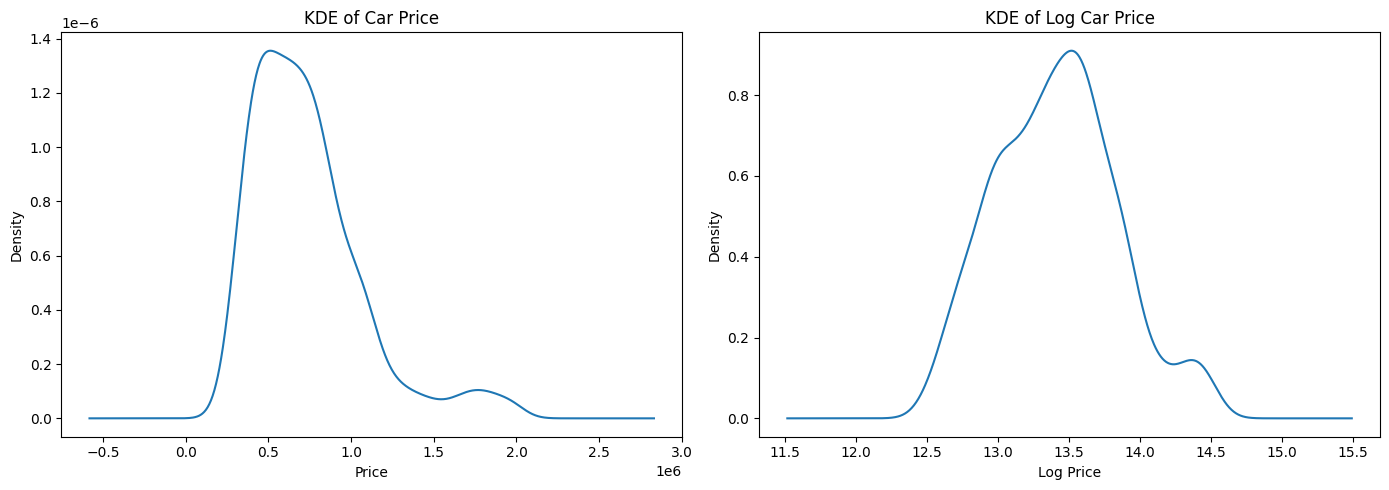


Price summary by brand:
               count          mean            std        min        25%  \
Make                                                                      
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Tata            20.0  1.087150e+06  476589.117419   548000.0   788750.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Toyota          50.0  8.003400e+05  246689.973986   368000.0   526250.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Hyundai        303.0  6.947525e+05  277837.000404   273000.0   491000.0   
Skoda            4.0  6.847500e+05  411730.797974   436000.0   458500.0   


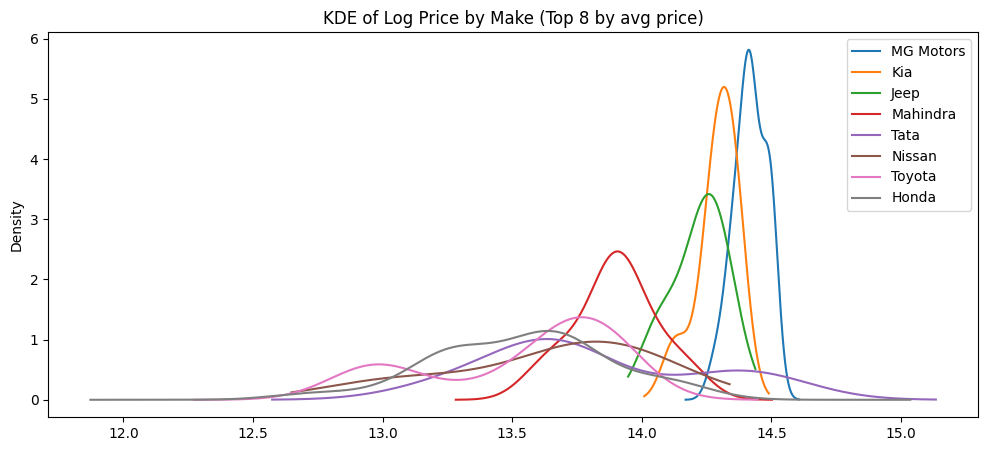

In [10]:
print(cars['Price'].describe())

# KDE of price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cars['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Car Price')
axes[0].set_xlabel('Price')

cars['log_Price'].plot.kde(ax=axes[1])
axes[1].set_title('KDE of Log Car Price')
axes[1].set_xlabel('Log Price')
plt.tight_layout()
plt.show()

# Summary by Make
brand_summary = cars.groupby('Make')['Price'].describe().sort_values('mean', ascending=False)
print("\nPrice summary by brand:")
print(brand_summary)

# Grouped KDE by Make (top 8 brands for readability)
top_makes = cars.groupby('Make')['Price'].mean().nlargest(8).index
fig, ax = plt.subplots(figsize=(12, 5))
for make in top_makes:
    cars[cars['Make'] == make]['log_Price'].plot.kde(ax=ax, label=make)
ax.set_title('KDE of Log Price by Make (Top 8 by avg price)')
ax.legend()
plt.show()

### Q3.3 — Train/Test Split

In [11]:
train, test = train_test_split(cars, test_size=0.2, random_state=42)
print(f"Train: {train.shape}, Test: {test.shape}")

Train: (764, 14), Test: (192, 14)


### Q3.4 — Three Models: Numeric only, Categorical only, Combined

In [12]:
target = 'log_Price'
num_cols = ['Make_Year', 'log_Mileage', 'Seating_Capacity']
cat_cols = ['Color', 'Body_Type', 'Make', 'Fuel_Type', 'Transmission', 'Transmission_Type']

def evaluate_model(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print(f"--- {label} ---")
    print(f"  Train R²: {r2_score(y_train, train_pred):.4f} | Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
    print(f"  Test  R²: {r2_score(y_test, test_pred):.4f} | Test  RMSE: {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")
    return model

# Model 1: Numeric only
X_num_train = train[num_cols]
X_num_test  = test[num_cols]
y_train = train[target]
y_test  = test[target]
m1 = evaluate_model(LinearRegression(), X_num_train, y_train, X_num_test, y_test, 'Numeric Only')

# Model 2: Categorical only (one-hot encoded)
dummies_train = pd.get_dummies(train[cat_cols], drop_first=True).astype(int)
dummies_test  = pd.get_dummies(test[cat_cols],  drop_first=True).astype(int)
dummies_test  = dummies_test.reindex(columns=dummies_train.columns, fill_value=0)
m2 = evaluate_model(LinearRegression(), dummies_train, y_train, dummies_test, y_test, 'Categorical Only')

# Model 3: Combined
X_comb_train = pd.concat([X_num_train.reset_index(drop=True), dummies_train.reset_index(drop=True)], axis=1)
X_comb_test  = pd.concat([X_num_test.reset_index(drop=True),  dummies_test.reset_index(drop=True)],  axis=1)
m3 = evaluate_model(LinearRegression(), X_comb_train, y_train.reset_index(drop=True), X_comb_test, y_test.reset_index(drop=True), 'Combined')

--- Numeric Only ---
  Train R²: 0.4004 | Train RMSE: 0.3383
  Test  R²: 0.3614 | Test  RMSE: 0.3075
--- Categorical Only ---
  Train R²: 0.6824 | Train RMSE: 0.2462
  Test  R²: 0.5457 | Test  RMSE: 0.2593
--- Combined ---
  Train R²: 0.8255 | Train RMSE: 0.1825
  Test  R²: 0.7850 | Test  RMSE: 0.1784


### Q3.5 — PolynomialFeatures on Numeric Variables

In [13]:
results = []
for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly.fit_transform(X_num_train)
    X_poly_test  = poly.transform(X_num_test)

    # Combine with categoricals
    X_full_train = np.hstack([X_poly_train, dummies_train.values])
    X_full_test  = np.hstack([X_poly_test,  dummies_test.values])

    m = LinearRegression()
    m.fit(X_full_train, y_train.reset_index(drop=True))
    test_pred = m.predict(X_full_test)
    r2  = r2_score(y_test.reset_index(drop=True), test_pred)
    rmse = np.sqrt(mean_squared_error(y_test.reset_index(drop=True), test_pred))
    results.append({'degree': degree, 'R2': r2, 'RMSE': rmse})
    print(f"Degree {degree} → Test R²: {r2:.4f} | Test RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results)
best = results_df.loc[results_df['R2'].idxmax()]
print(f"\nBest degree: {int(best['degree'])} | R²: {best['R2']:.4f} | RMSE: {best['RMSE']:.4f}")

Degree 1 → Test R²: 0.7850 | Test RMSE: 0.1784
Degree 2 → Test R²: 0.7924 | Test RMSE: 0.1753
Degree 3 → Test R²: 0.7951 | Test RMSE: 0.1742
Degree 4 → Test R²: 0.7960 | Test RMSE: 0.1738
Degree 5 → Test R²: 0.3822 | Test RMSE: 0.3024

Best degree: 4 | R²: 0.7960 | RMSE: 0.1738


### Q3.6 — Predicted vs True Values and Residuals

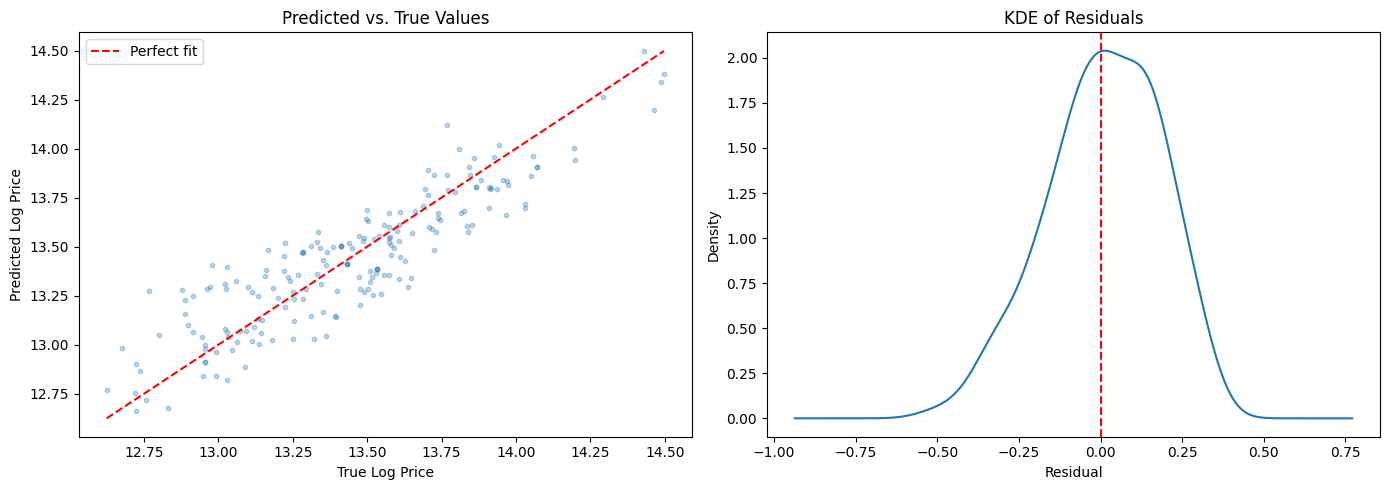

Residual mean: 0.0103
Residual std:  0.1739

Model evaluation:
- If points fall near the diagonal, predictions are accurate.
- Residuals should be bell-shaped and centered at zero for OLS assumptions to hold.


In [14]:
# Use best degree from above (adjust if needed)
best_degree = int(results_df.loc[results_df['R2'].idxmax(), 'degree'])
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_best_train = np.hstack([poly_best.fit_transform(X_num_train), dummies_train.values])
X_best_test  = np.hstack([poly_best.transform(X_num_test), dummies_test.values])

m_best = LinearRegression()
m_best.fit(X_best_train, y_train.reset_index(drop=True))
y_pred_best = m_best.predict(X_best_test)
y_true = y_test.reset_index(drop=True)
residuals = y_true - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs True
axes[0].scatter(y_true, y_pred_best, alpha=0.3, s=10)
min_val, max_val = y_true.min(), y_true.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect fit')
axes[0].set_xlabel('True Log Price')
axes[0].set_ylabel('Predicted Log Price')
axes[0].set_title('Predicted vs. True Values')
axes[0].legend()

# Residuals KDE
pd.Series(residuals).plot.kde(ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('KDE of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")
print("\nModel evaluation:")
print("- If points fall near the diagonal, predictions are accurate.")
print("- Residuals should be bell-shaped and centered at zero for OLS assumptions to hold.")

## Q4 — Math Derivations: Two-Variable Linear Regression

### Setup
Model: $\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}$, where $z_{ij} = x_{ij} - m_j$ (demeaned), so $\frac{1}{N}\sum_i z_{ij} = 0$.

---

### Q4.1 — SSE
$$SSE = \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2})^2$$

---

### Q4.2 — Partial Derivatives
$$\frac{\partial SSE}{\partial b_0} = -2\sum_i (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$
$$\frac{\partial SSE}{\partial b_1} = -2\sum_i z_{i1}(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$
$$\frac{\partial SSE}{\partial b_2} = -2\sum_i z_{i2}(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0$$

---

### Q4.3 — Average error = 0 and $e \cdot z = 0$
From the $b_0$ FOC: $\sum_i e_i = 0 \Rightarrow \bar{e} = 0$.
From the $b_1, b_2$ FOCs: $\sum_i z_{ij} e_i = 0$ for $j=1,2$. Same conditions as simple OLS.

---

### Q4.4 — Optimal intercept
From $\frac{\partial SSE}{\partial b_0} = 0$:
$$\sum_i y_i = Nb_0 + b_1\underbrace{\sum_i z_{i1}}_{=0} + b_2\underbrace{\sum_i z_{i2}}_{=0} \Rightarrow b_0^* = \bar{y}$$
Substituting $b_0^* = \bar{y}$ and defining $\tilde{y}_i = y_i - \bar{y}$, the remaining equations become:
$$\sum_i z_{i1}\tilde{y}_i = b_1 \sum_i z_{i1}^2 + b_2 \sum_i z_{i1}z_{i2}$$
$$\sum_i z_{i2}\tilde{y}_i = b_1 \sum_i z_{i1}z_{i2} + b_2 \sum_i z_{i2}^2$$

---

### Q4.5 — Normal Equations: $Ab = C$
$$\begin{pmatrix} \sum z_{i1}^2 & \sum z_{i1}z_{i2} \\ \sum z_{i1}z_{i2} & \sum z_{i2}^2 \end{pmatrix} \begin{pmatrix} b_1 \\ b_2 \end{pmatrix} = \begin{pmatrix} \sum z_{i1}\tilde{y}_i \\ \sum z_{i2}\tilde{y}_i \end{pmatrix}$$

---

### Q4.6 — Divide by $N$, substitute back $z_{ij} = x_{ij} - m_j$
Dividing by $N$:
$$A = \begin{pmatrix} \frac{1}{N}\sum z_{i1}^2 & \frac{1}{N}\sum z_{i1}z_{i2} \\ \frac{1}{N}\sum z_{i1}z_{i2} & \frac{1}{N}\sum z_{i2}^2 \end{pmatrix} = \begin{pmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) \\ \text{Cov}(x_1, x_2) & \text{Var}(x_2) \end{pmatrix}$$
$$C = \begin{pmatrix} \text{Cov}(x_1, y) \\ \text{Cov}(x_2, y) \end{pmatrix}$$
**Intuition**: $A$ is the **variance-covariance matrix** of the predictors, and $C$ is the vector of **covariances between each predictor and $y$**. The normal equations say $b = A^{-1}C$: each slope is determined by how the predictors vary jointly and how they co-vary with $y$, exactly generalizing the single-variable formula $b_1 = \text{Cov}(x,y)/\text{Var}(x)$.